In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
##importando todas as bibliotecas usadas no curso

sns.set(style="whitegrid")  #fundo branco para os gráficos
np.random.seed(42)

In [2]:
#dataset base para o meu programa
n = 500
ages = np.random.randint(18, 70, n)
page_speed = np.random.normal(3.0, 1.0, n)
purchase_amount = 50 + (ages * 0.5) + np.random.normal(0, 10, n)

data = pd.DataFrame({
    "Age": ages,
    "PageSpeed": page_speed,
    "PurchaseAmount": purchase_amount
})

data.head() #5 primeiros dados - Aqui temos idade, compra e velocidade da página (exemplo modificado do usado na aula)

,Age,PageSpeed,PurchaseAmount
0,56,5.122156,68.241267
1,69,4.032465,95.036418
2,46,1.480630,63.506011
3,32,2.515766,92.323821
4,60,4.266911,84.933179


In [11]:
print("Mean:", data["PurchaseAmount"].mean()) #media
print("Median:", data["PurchaseAmount"].median()) #mediana
print("Mode:", data["Age"].mode()[0]) #moda

Mean: 73.38981397708967
Median: 73.48718459414157
Mode: 50


In [12]:
print("Variance:", data["PurchaseAmount"].var()) #desvio padrão e variância
print("Standard Deviation:", data["PurchaseAmount"].std())


Variance: 148.4522165922443
Standard Deviation: 12.18409687224475


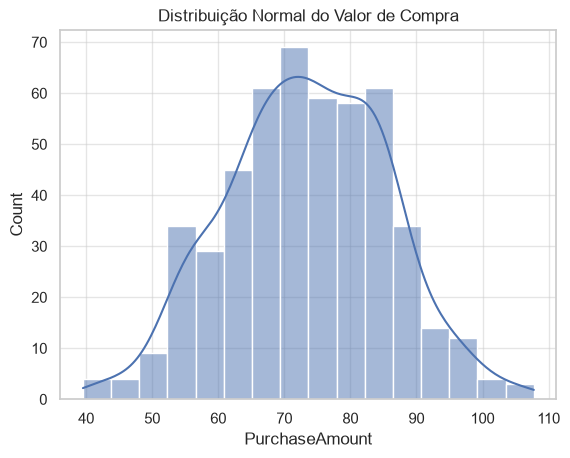

In [14]:
sns.histplot(data["PurchaseAmount"], kde=True)
plt.title("Distribuição Normal do Valor de Compra") #hisograma normal
plt.show()


In [16]:
print("25th percentile:", np.percentile(data["PurchaseAmount"], 25))
print("75th percentile:", np.percentile(data["PurchaseAmount"], 75))
print("Skewness:", data["PurchaseAmount"].skew()) #porcento
print("Kurtosis:", data["PurchaseAmount"].kurt())


25th percentile: 65.15051969636438
75th percentile: 82.43396877101634
Skewness: -0.04902226608131134
Kurtosis: -0.22981205322497011


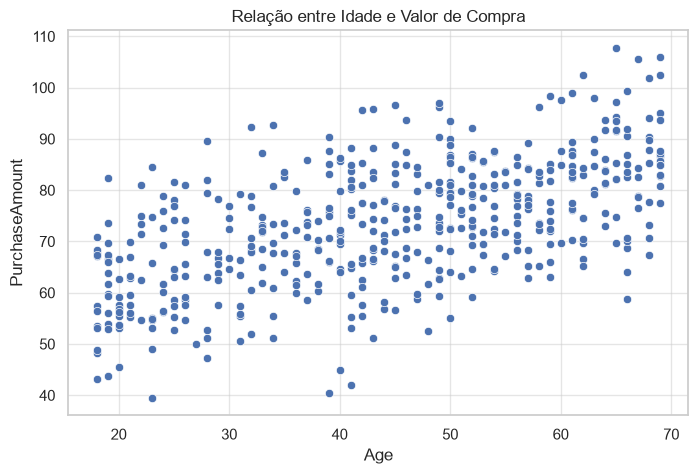

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="PurchaseAmount", data=data)
plt.title("Relação entre Idade e Valor de Compra")
plt.show()


In [18]:
cov = np.cov(data["Age"], data["PurchaseAmount"])[0][1]
corr = np.corrcoef(data["Age"], data["PurchaseAmount"])[0][1]
print("Covariance:", cov)
print("Correlation:", corr) #probabilidade condicional


Covariance: 107.22686590102464
Correlation: 0.5852960297077038


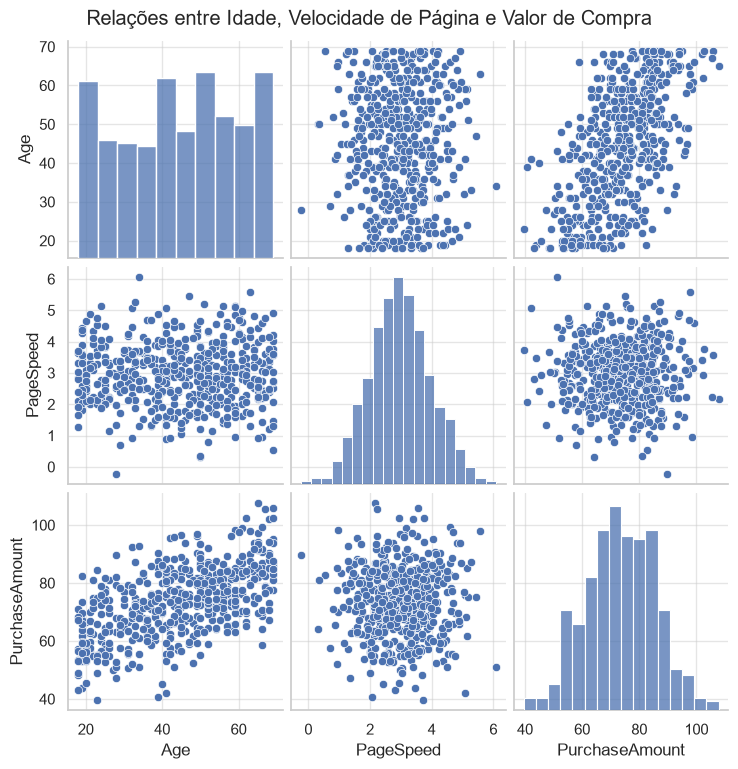

In [23]:
sns.pairplot(data)
plt.suptitle("Relações entre Idade, Velocidade de Página e Valor de Compra", y=1.02)
plt.show() #todos os tipos de gráfico junto


In [27]:
import scipy.stats as sp
sp.skew(data["PurchaseAmount"])

np.float64(-0.04887507655554807)

In [29]:
sp.mode(data["PurchaseAmount"])

ModeResult(mode=np.float64(39.51194043379918), count=np.int64(1))

In [30]:
sp.kurtosis(data["PurchaseAmount"]) #explorando a scipy

np.float64(-0.23949640616762258)

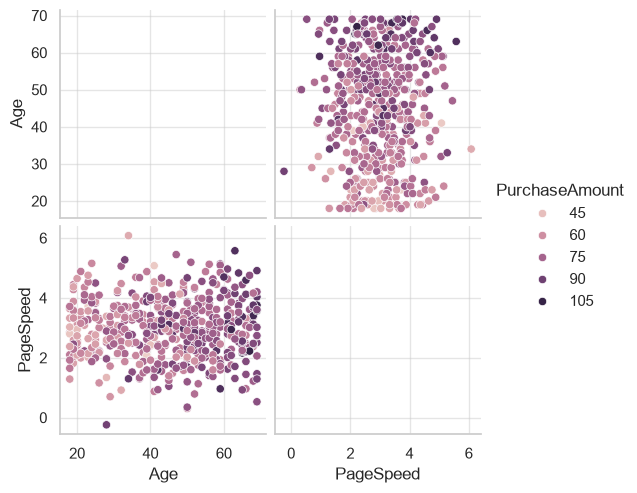

In [32]:
sns.pairplot(data, hue = 'PurchaseAmount', height=2.5); #outro tipo de grafico

array([[ 1., -1.],
       [-1.,  1.]])

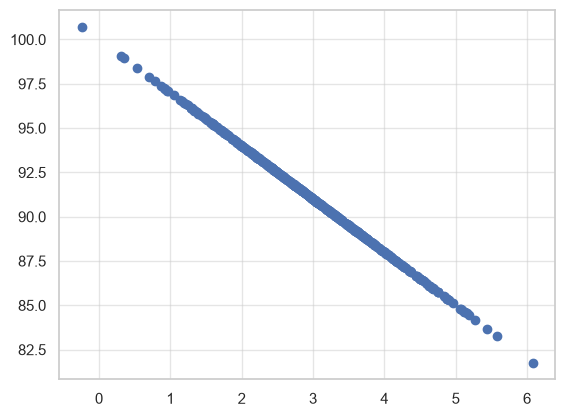

In [36]:
data["PurchaseAmount"] = 100 - data["PageSpeed"] * 3
plt.scatter(data["PageSpeed"], data["PurchaseAmount"])
np.corrcoef(data["PageSpeed"], data["PurchaseAmount"]) #foçando a mesma correlação do exercício da aula

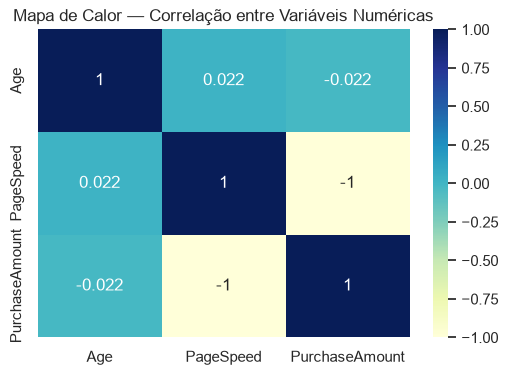

In [43]:
corr = data.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Mapa de Calor — Correlação entre Variáveis Numéricas") #mapa de calor - só funcionou com numeros aqui
plt.show()
